# インド株 ファクター検証 — Step 12: 税制調整 CGO（LIO / RO / TLO の3成分分解）

コホート $n$ 日前取得の含み益率 $g_n = (P_{t-1} - P_{t-n})/P_{t-1}$ と
重み $\omega_n = V_{t-n}\prod_{\tau<n}(1-V_{t-n+\tau})/k$ に対して、
LTCG 境界（**252営業日** = 12ヶ月）を基準に3成分へ分解する。

| 成分 | 定義（日次） | 仮説の符号 |
|---|---|---|
| **LIO**（ロックイン） | $\sum_{n<252}\omega_n \max(g_n,0)\,e^{-(252-n)/h}$ | **+**（節税待ちで売り繰延べ → 過小反応） |
| **RO**（リリース） | $\sum_{252\le n<252+\Delta}\omega_n \max(g_n,0)\,e^{-(n-252)/h}$ | **−**（境界通過で繰延べ売りが解放） |
| **TLO**（税損売り） | $\sum_{n<252}\omega_n \max(-g_n,0)\,e^{-(252-n)/h}$ | **−**（1年到達前の損失実現の売り圧） |

既定パラメータ: $N=1260$、$\Delta=63$、$h=42$ 営業日（= 週次案の 4〜13週の中間 8週）。
**λ による合成はせず、3成分を Fama-MacBeth に別々に投入して符号で判定**する
（自由度を増やさないため。$h$ は感応度として 21/42/63 を報告、チューニングはしない）。

## 制度上の重要事実（検証軸）

1. **2018年3月以前、上場株の LTCG は非課税**（STT 済み）。2018年4月に 10% 課税開始
   （grandfathering あり）、2024年7月に 12.5% へ。STCG は 15% → 20%（2024年7月）。
   → ロックイン誘因（Δτ）は **pre-2018 が最大**（15% vs 0%）。サブ期間で効果が
   単調に弱まる（または STCG 増税の 2024 年以降に再強化）なら仮説と整合
2. **インドの課税年度は 4月〜3月** → 税損売り（TLO）は **2〜3月に季節性**が出るはず

## 事前の見立て（Step 10・11 の結果から）

- RO が最も筋が良い（naive CGO が符号逆の売り圧コホートを混入しているという指摘は
  既存ファクターとの明確な差分）
- TLO は逆風（Step 10: 損側の濃淡は無情報）。ただし「境界手前×税動機」は別仮説
- Step 11 でターム構造に 12m 不連続は見えなかったが、あれは鈍い検定
  （隣接 N の CGO は重みの96%超を共有）。本分解の方がシャープ

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 260, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.4f}")

START, END = 200801, 202607
Q = 5
FIGDIR = "12_tax_cgo"
COMPS = ["lio", "ro", "tlo"]
EXPECTED = {"lio": "+", "ro": "-", "tlo": "-"}

## 1. 計算（h = 42 を既定、21 / 63 は感応度用）

カーネルはナイーブ実装と一致検証済み（1e-17）。

In [2]:
t0 = time.time()
tax = fl.cgo.monthly_tax_cgo(start=START, end=END, h_lock=42, h_rel=42)
tax_h = {h: fl.cgo.monthly_tax_cgo(start=START, end=END, h_lock=h, h_rel=h)
         for h in (21, 63)}
tax_h[42] = tax
print(f"{time.time()-t0:.1f} 秒")

panel = fl.data.build_panel(["mom12_1", "mom1"], start=START, end=END)
panel["cgo_60m"] = fl.cgo.load_cgo_monthly(["cgo_60m"], start=START, end=END)["cgo_60m"].reindex(panel.index)
for c in COMPS:
    panel[c] = tax[c].reindex(panel.index)
tax.describe().T[["count", "mean", "std", "50%", "max"]]

28.2 秒


,count,mean,std,50%,max
lio,"142,248.0000",0.0072,0.0109,0.0025,0.2768
ro,"142,248.0000",0.0054,0.0089,0.0016,0.2912
tlo,"142,248.0000",0.0162,0.1022,0.0015,16.8156


## 2. 特性と相関

In [3]:
chars = fl.altdata.score_characteristics(panel, COMPS + ["cgo_60m"])
display(chars[["n_stocks_mean", "coverage_univ", "frac_mode", "rank_autocorr"]])

panel = fl.preprocess.standardize_panel(panel, COMPS + ["cgo_60m", "mom12_1", "mom1"], method="blom")
cols = [f"{c}_blom" for c in COMPS + ["cgo_60m", "mom12_1"]]
fl.multi.cross_sectional_corr(panel, cols, labels=COMPS + ["cgo_60m", "mom12_1"])

,n_stocks_mean,coverage_univ,frac_mode,rank_autocorr
lio,317.4843,0.8540,0.0310,0.8741
ro,317.4843,0.8540,0.2902,0.8972
tlo,317.4843,0.8540,0.0381,0.8501
cgo_60m,317.4843,0.8540,0.0034,0.9411


,lio,ro,tlo,cgo_60m,mom12_1
lio,1.0000,0.7895,-0.7197,0.6655,0.7213
ro,0.7895,1.0000,-0.6847,0.7067,0.7388
tlo,-0.7197,-0.6847,1.0000,-0.7734,-0.6566
cgo_60m,0.6655,0.7067,-0.7734,1.0000,0.6479
mom12_1,0.7213,0.7388,-0.6566,0.6479,1.0000


## 3. 単変量: IC と分位（仮説の符号と比較）

In [4]:
rows = {}
ics = {}
for c in COMPS:
    ics[c] = fl.ic.information_coefficient(panel, f"{c}_blom", "fwd_rtn")
    res = fl.quantile.quantile_returns(panel, f"{c}_blom", q=Q, ascending=True)
    s = fl.quantile.quantile_summary(res, weighting="ew")
    i = fl.ic.ic_summary(ics[c])
    rows[c] = {"expected_sign": EXPECTED[c], "mean_IC": i["mean_IC"], "IC_t_NW": i["t_stat_NW"],
               "ls_ann_excess": s.loc[f"Q{Q}-Q1", "ann_excess"],
               "ls_t_NW": s.loc[f"Q{Q}-Q1", "t_stat_NW"]}
pd.DataFrame(rows).T

,expected_sign,mean_IC,IC_t_NW,ls_ann_excess,ls_t_NW
lio,+,0.0400,4.0100,0.0932,2.8264
ro,-,0.0448,3.8200,0.0743,2.2680
tlo,-,-0.0469,-3.9772,-0.1047,-1.7330


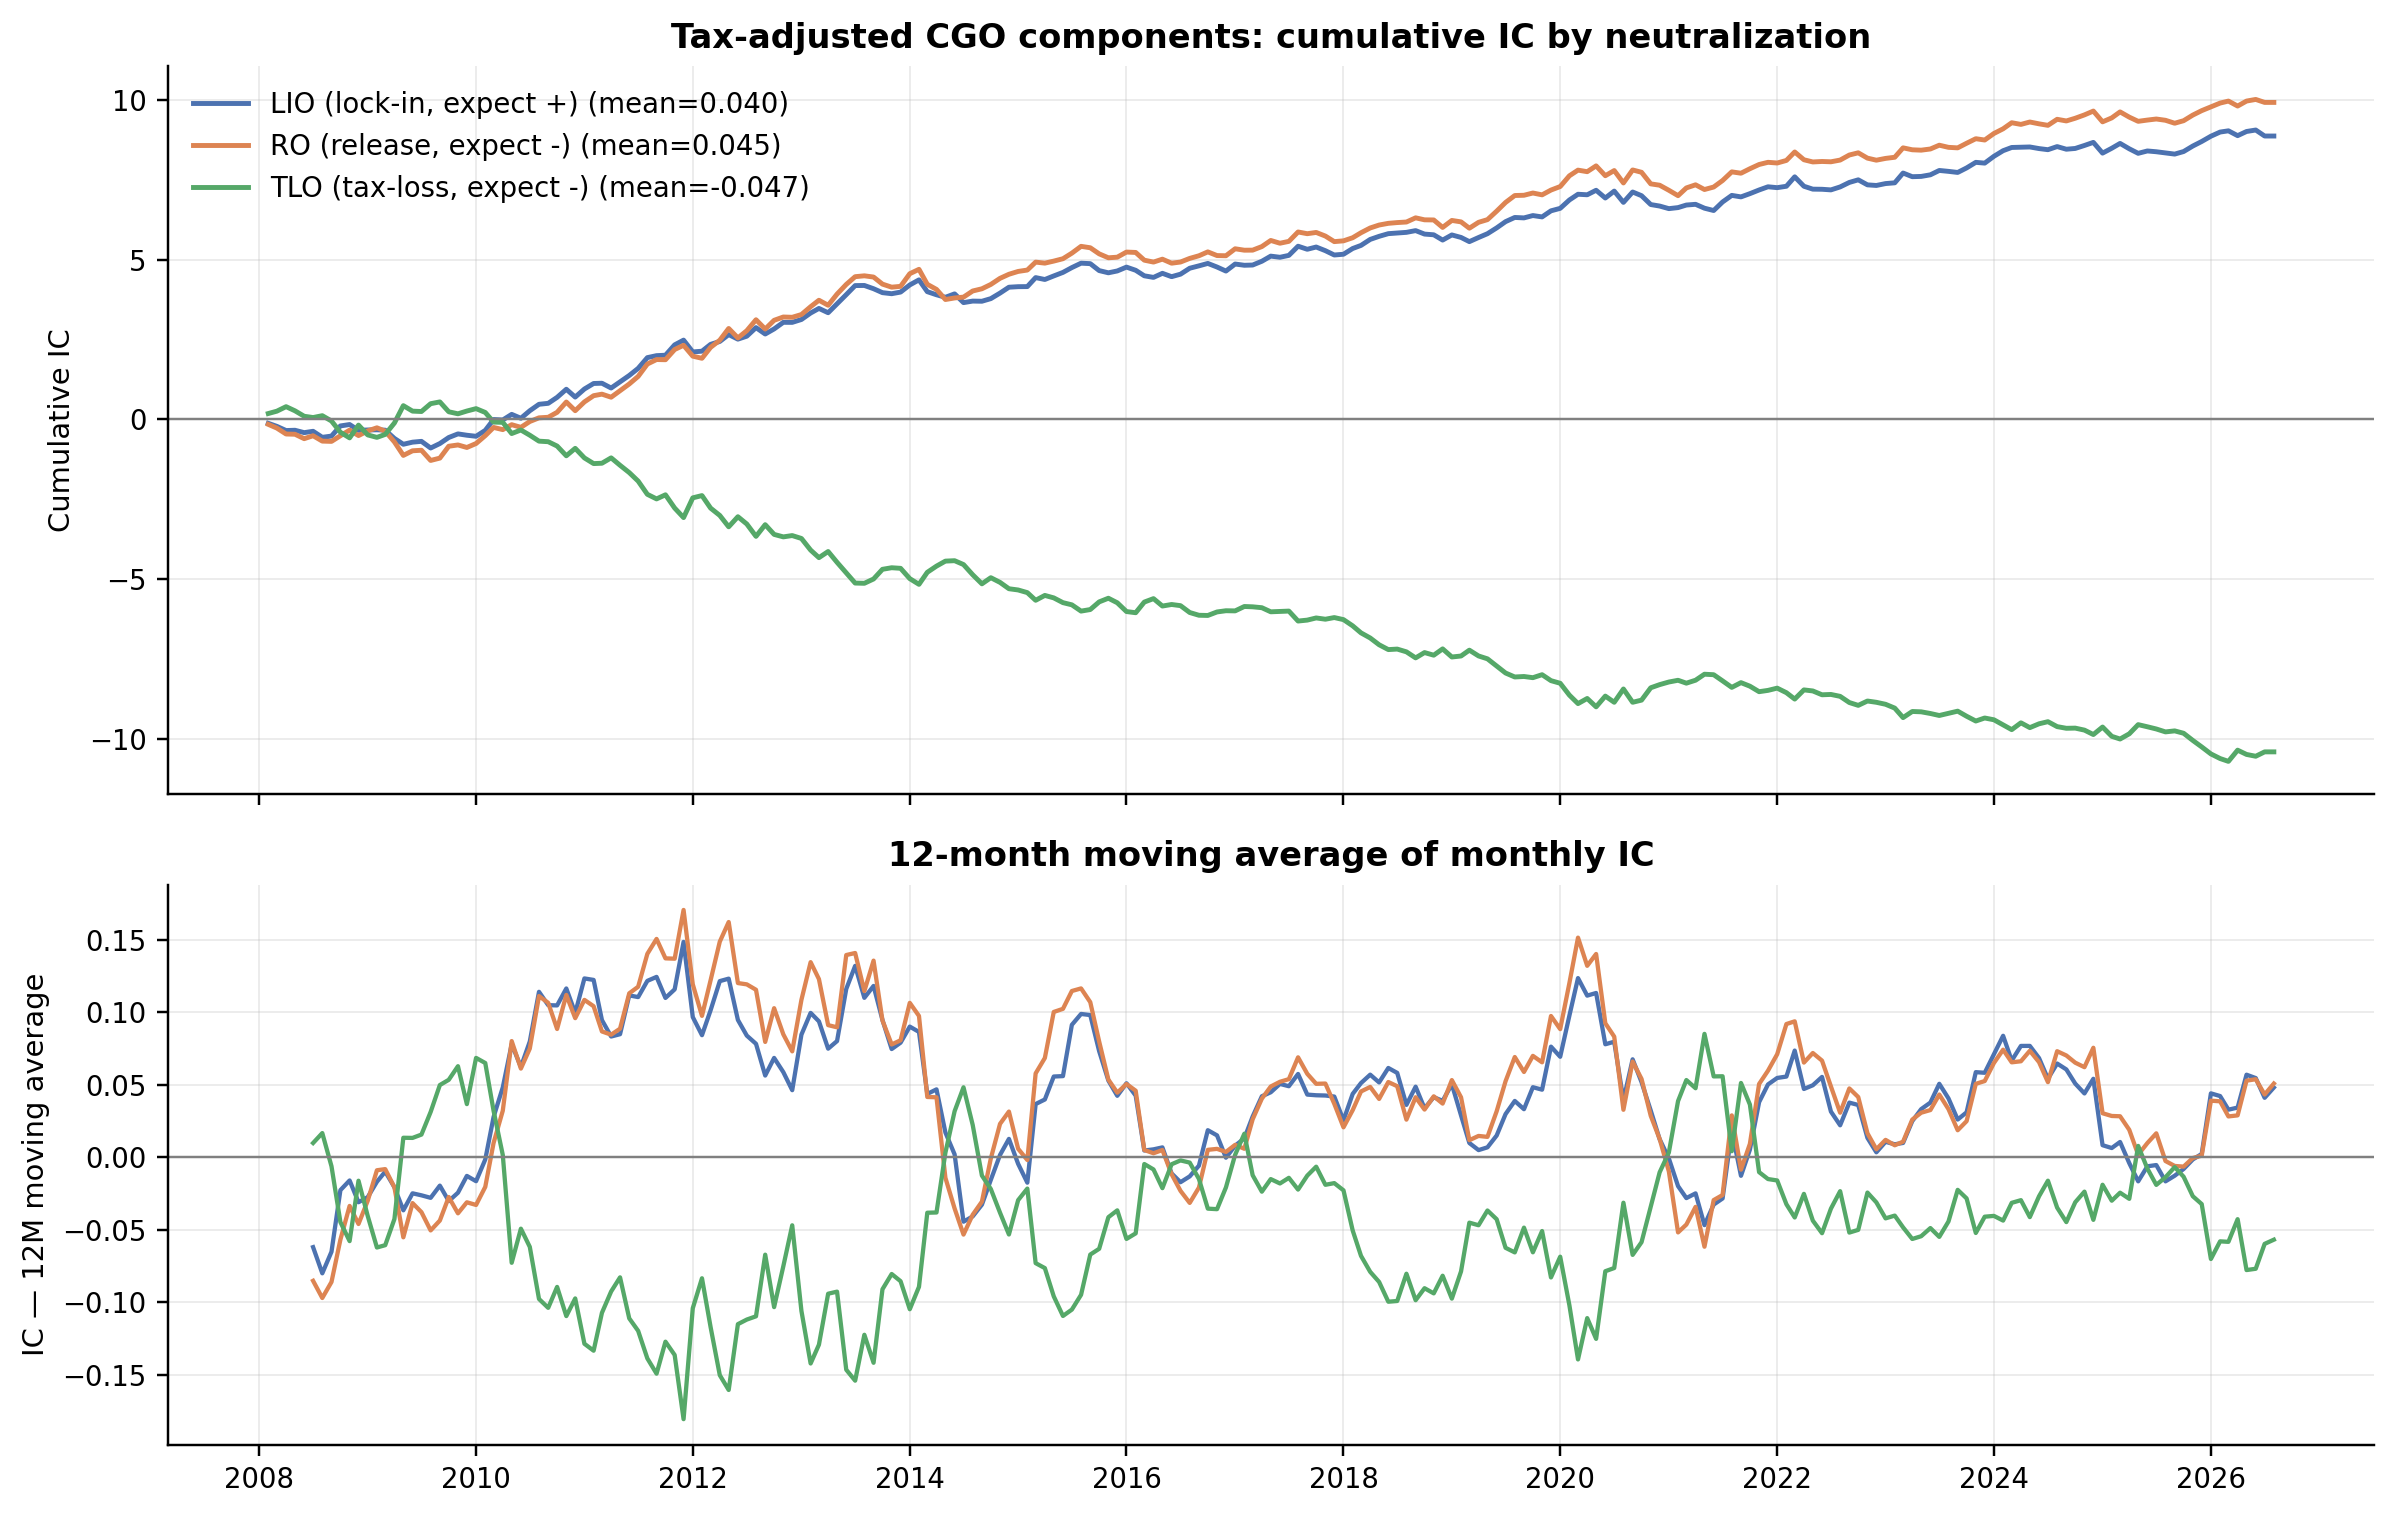

In [5]:
fig = fl.plotting.plot_cumulative_ic_compare(
    ics, factor="Tax-adjusted CGO components",
    labels={"lio": "LIO (lock-in, expect +)", "ro": "RO (release, expect -)",
            "tlo": "TLO (tax-loss, expect -)"})
fl.plotting.savefig(fig, f"{FIGDIR}/95_components_cumulative_ic");

## 4. Fama-MacBeth（本命の検定）

3成分同時、さらに cgo_60m・mom12_1 を足した「増分」版。
係数は Blom スコア1SDあたりの月次リターン。

In [6]:
_, fm1 = fl.regression.fama_macbeth(panel, [f"{c}_blom" for c in COMPS])
_, fm2 = fl.regression.fama_macbeth(panel, [f"{c}_blom" for c in COMPS] +
                                    ["cgo_60m_blom", "mom12_1_blom", "mom1_blom"])
print("=== (1) 3成分のみ ===")
display(fm1)
print("=== (2) + cgo_60m + mom12_1 + mom1（増分検定） ===")
display(fm2)

=== (1) 3成分のみ ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0117,2.2070,1.9538,0.5721,222.0000
lio_blom,0.0013,1.1873,1.2886,0.5450,222.0000
ro_blom,0.0010,0.7507,0.6624,0.5495,222.0000
tlo_blom,-0.0010,-0.6020,-0.6709,0.4595,222.0000


=== (2) + cgo_60m + mom12_1 + mom1（増分検定） ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0118,2.2316,1.9766,0.5721,222.0000
lio_blom,0.0004,0.3344,0.3439,0.4820,222.0000
ro_blom,-0.0001,-0.1081,-0.1039,0.4820,222.0000
tlo_blom,-0.0012,-0.9482,-0.8279,0.4414,222.0000
cgo_60m_blom,0.0015,1.2485,1.1806,0.5495,222.0000
mom12_1_blom,0.0014,0.7172,0.6142,0.5360,222.0000
mom1_blom,-0.0020,-2.0852,-2.1720,0.4369,222.0000


## 5. h の感応度（チューニングではなく頑健性の確認）

In [7]:
rows = {}
for h, df in sorted(tax_h.items()):
    p2 = panel.copy()
    for c in COMPS:
        p2[f"{c}_h"] = df[c].reindex(p2.index)
    p2 = fl.preprocess.standardize_panel(p2, [f"{c}_h" for c in COMPS], method="blom")
    _, fm = fl.regression.fama_macbeth(p2, [f"{c}_h_blom" for c in COMPS])
    for c in COMPS:
        rows[(f"h={h}", c)] = {"mean_coef": fm.loc[f"{c}_h_blom", "mean"],
                               "t_NW": fm.loc[f"{c}_h_blom", "t_NW"]}
pd.DataFrame(rows).T

mean_coef    t_NW
h=21 lio     0.0016  1.7262
     ro      0.0007  0.4642
     tlo    -0.0008 -0.5536
h=42 lio     0.0013  1.2886
     ro      0.0010  0.6624
     tlo    -0.0010 -0.6709
h=63 lio     0.0010  0.9239
     ro      0.0013  0.8312
     tlo    -0.0012 -0.7768

## 6. 税制レジーム別（LTCG: 〜2018.03 = 0% / 2018.04〜2024.06 = 10% / 2024.07〜 = 12.5%）

In [8]:
coefs, _ = fl.regression.fama_macbeth(panel, [f"{c}_blom" for c in COMPS])
regimes = {"pre-2018.04 (LTCG 0%)": coefs.index < 201804,
           "2018.04-2024.06 (10%)": (coefs.index >= 201804) & (coefs.index < 202407),
           "2024.07+ (12.5/20%)": coefs.index >= 202407}
rows = {}
for name, mask in regimes.items():
    sub = coefs[mask]
    for c in COMPS:
        col = f"{c}_blom"
        rows[(name, c)] = {"mean_coef": sub[col].mean(),
                           "t_NW": fl.metrics.newey_west_tstat(sub[col]),
                           "n_months": len(sub)}
pd.DataFrame(rows).T

mean_coef    t_NW  n_months
pre-2018.04 (LTCG 0%) lio     0.0024  1.7807  123.0000
                      ro     -0.0016 -0.6820  123.0000
                      tlo    -0.0019 -0.8288  123.0000
2018.04-2024.06 (10%) lio     0.0009  0.4793   75.0000
                      ro      0.0037  1.8357   75.0000
                      tlo     0.0003  0.1654   75.0000
2024.07+ (12.5/20%)   lio    -0.0028 -1.0429   24.0000
                      ro      0.0061  2.1202   24.0000
                      tlo    -0.0006 -0.1175   24.0000

## 7. TLO の季節性（課税年度末 = 3月）

TLO の FM 係数をカレンダー月別に平均。仮説どおりなら 2〜3月に負が集中するはず。

,lio,ro,tlo
calendar_month,,,
1,-0.0017,-0.0000,-0.0102
2,-0.0006,0.0012,-0.0062
3,0.0044,0.0028,0.0211
4,0.0026,-0.0097,-0.0054
5,0.0029,-0.0057,-0.0038
6,0.0006,0.0055,-0.0038
7,-0.0040,0.0070,-0.0086
8,-0.0003,0.0034,-0.0012
9,0.0063,0.0047,0.0048


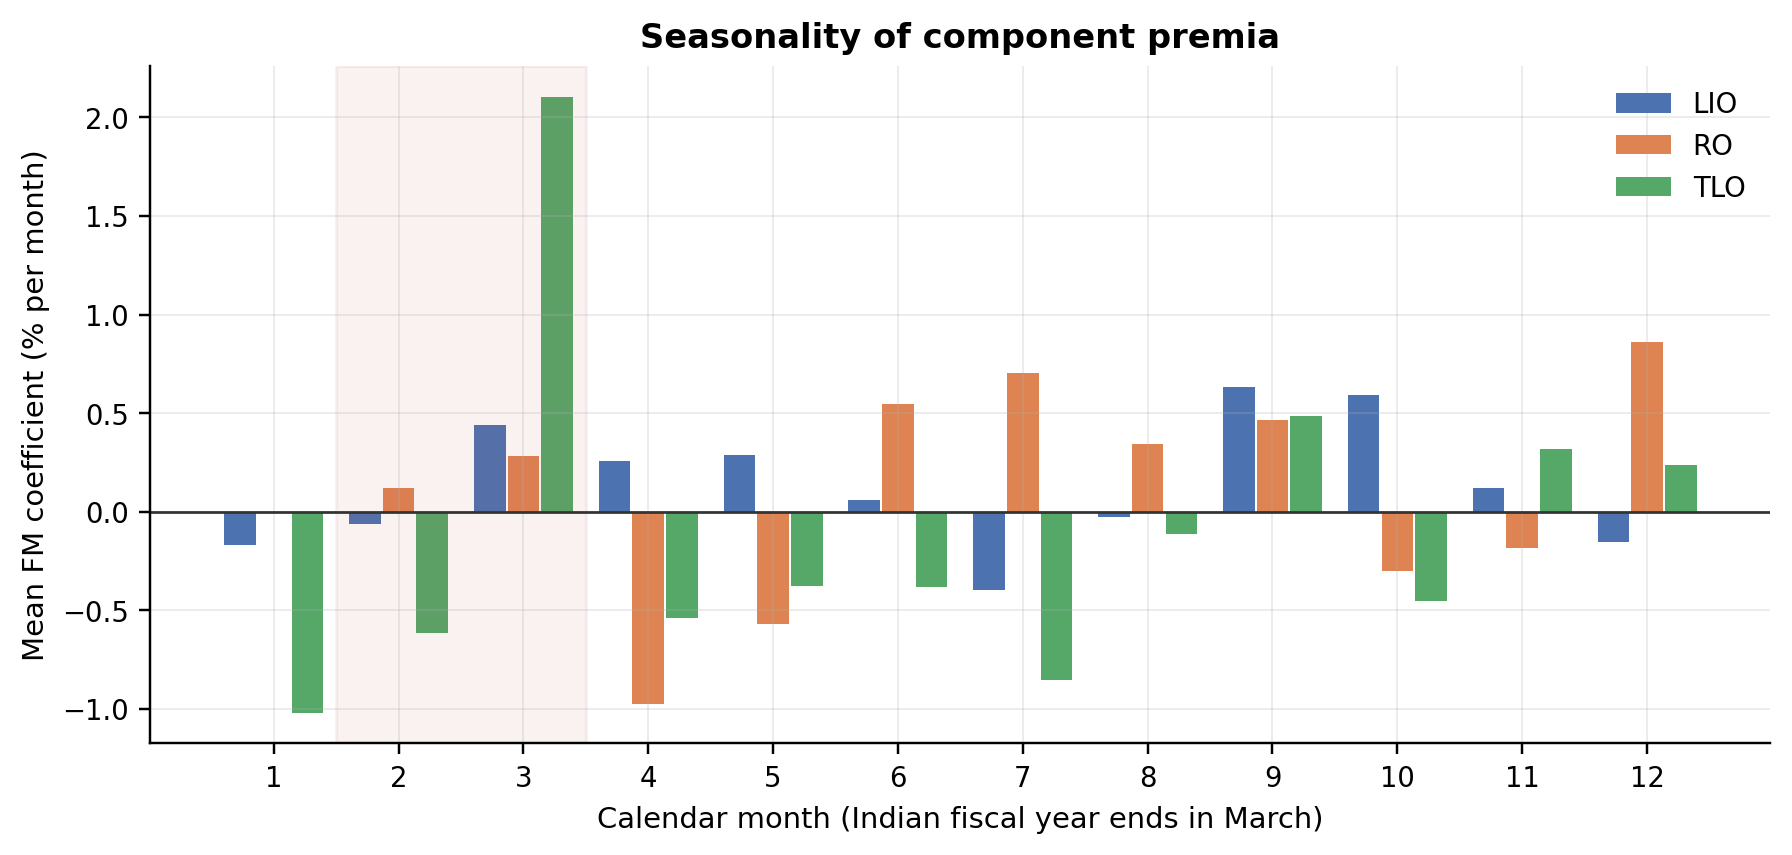

In [9]:
month = coefs.index % 100
seas = coefs.groupby(month)[[f"{c}_blom" for c in COMPS]].mean()
seas.columns = COMPS
seas.index.name = "calendar_month"

fig, ax = plt.subplots(figsize=(9.5, 4.0))
x = np.arange(1, 13)
w = 0.27
for j, c in enumerate(COMPS):
    ax.bar(x + (j - 1) * w, seas[c].reindex(x) * 100, width=w * 0.94,
           label=c.upper(), color=["#4C72B0", "#DD8452", "#55A868"][j])
ax.axhline(0, color="#333333", linewidth=0.9)
ax.set_xticks(x)
ax.set_xlabel("Calendar month (Indian fiscal year ends in March)")
ax.set_ylabel("Mean FM coefficient (% per month)")
ax.set_title("Seasonality of component premia")
ax.axvspan(1.5, 3.5, color="#C44E52", alpha=0.08)
ax.legend()
fl.plotting.savefig(fig, f"{FIGDIR}/96_seasonality")
seas.round(4)

---

## 判定の枠組み（再掲）

- LIO: FM 係数が **正** で有意か、cgo_60m/mom を入れても残るか
- RO: **負** で有意か（naive CGO との差分の核心）
- TLO: **負** か、2〜3月に集中するか
- レジーム: pre-2018（Δτ 最大）で最強なら税メカニズムと整合。
  全期間で同符号・レジーム無差別なら「税ではなく一般的な行動バイアス」の解釈が残る